### step 1 : importing Necessary Libraies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as st
import warnings
warnings.filterwarnings("ignore")


### step 2 : Load the data using Pandas

In [2]:
data=pd.read_csv(r"C:\Users\Admin\Downloads\bank_messy_dataset.csv")
data

,Customer_ID,Name,Age,Gender,Account_Type,Account_Balance,Loan_Amount,Loan_Status,Credit_Score,Monthly_Income,Employment_Status,Transaction_Count,Phone,City,Late_Payments
0,1,Aditya Desai,56.0,M,FD,50819.73580,0,Pending,746.354752,39442.54268,Self-Employed,166,5.763597e+09,Pune,6
1,2,Ravi Nair,69.0,male,current,66589.47858,200000,Pending,671.919250,42011.77000,Self-Employed,71,3.101714e+09,Nagpur,0
2,3,Sakshi Sharma,46.0,Female,Current,28527.41988,0,Approved,698.094606,33794.29135,salaried,297,4.975047e+08,Mumbai,3
3,4,Neha Nair,32.0,Male,Savings,57285.46812,0,Approved,752.657860,34311.31156,salaried,8,5.421995e+09,Nagpur,12
4,5,Amit Verma,NaN,female,Current,33419.25083,50000,Rejected,572.189382,39926.60102,Salaried,280,-5.319325e+09,Pune,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Neha Sharma,18.0,Female,FD,79182.14315,0,approved,703.637008,46429.54365,Salaried,237,3.611607e+09,Mumbai,10
996,997,Karan Rao,35.0,F,Current,33372.01065,0,Pending,577.186440,55270.26720,salaried,134,NaN,delhi,12
997,998,Sneha Nair,49.0,male,current,63951.73201,0,Pending,786.163655,55039.07338,salaried,279,5.611354e+08,mumbai,14
998,999,Ravi Desai,64.0,M,savings,49499.82587,200000,Approved,522.523975,49687.38504,salaried,18,5.115705e+09,mumbai,1


### step 3 : Data Understanding
1. Customer_ID 
- Type: Numerical (Discrete) 
- Description: Unique identifier assigned to each customer. 
- Notes: Used for record tracking; no analytical meaning. 
2. Name 
- Type: Categorical (Nominal) 
- Description: Full name of the customer. 
- Notes: May include inconsistent formats (upper/lowercase, extra spaces). 
3. Age 
- Type: Numerical (Continuous) 
- Description: Age of the customer in years. 
- Notes: May contain missing values or unrealistic ages (e.g., <18 or >90). 
4. Gender 
- Type: Categorical (Nominal) 
- Description: Gender of the customer (Male/Female). 
- Notes: Includes inconsistent entries (e.g., “M”, “male”, “FEMALE”, “f”). 
5. Account_Type 
- Type: Categorical (Nominal) 
- Description: Type of bank account held (Savings, Current, Salary, Joint). 
- Notes: Contains typos and mixed-format values. 
6. Account_Balance 
- Type: Numerical (Continuous) 
- Description: Current available balance in the customer’s account (INR). 
- Notes: Contains outliers and missing values. 
7. Loan_Amount 
- Type: Numerical (Continuous) 
- Description: Total sanctioned loan amount for the customer. 
- Notes: May include extreme values and incorrect entries. 
8. Loan_Status 
- Type: Categorical (Nominal) 
- Description: Status of the customer’s loan (Approved / Rejected / Pending). 
- Notes: Includes inconsistent labels (“APPROVED”, “approved”, “A”, etc.). 
9. Credit_Score 
- Type: Numerical (Continuous) 
- Description: Credit rating of the customer (300–900 scale). 
- Notes: Outliers possible; useful for credit risk analysis. 
10. Monthly_Income 
- Type: Numerical (Continuous) 
- Description: Customer’s monthly income in INR. 
- Notes: Contains missing values and noise. 
11. Employment_Status 
- Type: Categorical (Nominal) 
- Description: Type of employment (Salaried, Self-Employed, Unemployed, Student). 
- Notes: May contain typos and inconsistent capitalization. 
12. Transaction_Count 
- Type: Numerical (Discrete) 
- Description: Number of monthly bank transactions made by the customer. 
- Notes: Missing values possible; used in behavior-based segmentation. 
13. Phone 
- Type: Categorical (Nominal) 
- Description: Customer’s phone number. 
- Notes: Contains formatting inconsistencies, missing digits, symbols. 
14. City 
- Type: Categorical (Nominal) 
- Description: Customer’s city of residence. 
- Notes: Contains NULLs and inconsistent spellings (e.g., “Mumbai”, “mumbai”, “Bombay”). 
15. Late_Payments 
- Type: Numerical (Discrete) 
- Description: Number of late EMI/credit-card payments recorded. 
- Notes: May include extremely high values due to input errors. 
Includes missing values, outliers, inconsistent formats, categorical noise, typos, mixed data types.

### Step 4 : EDA (Exploratory Data Analysis)
- Describe the data statistically 
   - shape
   - describe
   - info
   - dtypes
   - null value checking
   - duplicate values checking
- missing value Handling
- Outlier Handling 
- univariate and bivariate Analysis to understand each and every column

In [3]:
data.shape

(1000, 15)

In [4]:
data.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Account_Type',
       'Account_Balance', 'Loan_Amount', 'Loan_Status', 'Credit_Score',
       'Monthly_Income', 'Employment_Status', 'Transaction_Count', 'Phone',
       'City', 'Late_Payments'],
      dtype='object')

In [5]:
data2=data[['Age', 'Gender', 'Account_Type',
       'Account_Balance', 'Loan_Amount', 'Loan_Status', 'Credit_Score',
       'Monthly_Income', 'Employment_Status', 'Transaction_Count',
       'City', 'Late_Payments']]
data2

,Age,Gender,Account_Type,Account_Balance,Loan_Amount,Loan_Status,Credit_Score,Monthly_Income,Employment_Status,Transaction_Count,City,Late_Payments
0,56.0,M,FD,50819.73580,0,Pending,746.354752,39442.54268,Self-Employed,166,Pune,6
1,69.0,male,current,66589.47858,200000,Pending,671.919250,42011.77000,Self-Employed,71,Nagpur,0
2,46.0,Female,Current,28527.41988,0,Approved,698.094606,33794.29135,salaried,297,Mumbai,3
3,32.0,Male,Savings,57285.46812,0,Approved,752.657860,34311.31156,salaried,8,Nagpur,12
4,NaN,female,Current,33419.25083,50000,Rejected,572.189382,39926.60102,Salaried,280,Pune,14
...,...,...,...,...,...,...,...,...,...,...,...,...
995,18.0,Female,FD,79182.14315,0,approved,703.637008,46429.54365,Salaried,237,Mumbai,10
996,35.0,F,Current,33372.01065,0,Pending,577.186440,55270.26720,salaried,134,delhi,12
997,49.0,male,current,63951.73201,0,Pending,786.163655,55039.07338,salaried,279,mumbai,14
998,64.0,M,savings,49499.82587,200000,Approved,522.523975,49687.38504,salaried,18,mumbai,1


In [6]:
data2.shape

(1000, 12)

There are 1000 row and 15 columns in our data.but we can remove "customer id","customer_name","phone" columnn bcoz they are not important for the analysis 
so after the removing column we have 12 columns and the 1000 rows

In [7]:
data2.dtypes

Age                  float64
Gender                object
Account_Type          object
Account_Balance      float64
Loan_Amount            int64
Loan_Status           object
Credit_Score         float64
Monthly_Income       float64
Employment_Status     object
Transaction_Count      int64
City                  object
Late_Payments          int64
dtype: object

In [8]:
data2.describe()

,Age,Account_Balance,Loan_Amount,Credit_Score,Monthly_Income,Transaction_Count,Late_Payments
count,950.000000,952.000000,1000.000000,950.000000,950.000000,1000.000000,1000.000000
mean,49.902105,55554.478106,98450.000000,648.575835,34770.683184,150.962000,6.954000
std,18.201422,50552.331223,110554.601079,72.665158,11771.368205,86.583389,4.309113
min,18.000000,-17736.275230,0.000000,439.465736,-3120.445758,0.000000,0.000000
25%,35.000000,37611.782088,0.000000,599.106122,27098.578487,75.750000,3.000000
50%,50.000000,51678.633790,50000.000000,649.829288,34756.044145,153.000000,7.000000
75%,66.000000,64629.400415,200000.000000,695.994639,42869.240728,227.000000,11.000000
max,79.000000,508073.265200,300000.000000,877.016508,72354.922410,299.000000,14.000000


### age 
- mean	49.902105
- median 50.00
- std	18.201422
- max   79
- when std < mean there are No Outliers present in Age column

#### Loan Amount
- Mean   =  00.00
- median = 	50000
- std    =  110554.60
- when std > mean there will be outliers

#### Account_Balance
- Mean   = 55554.47
- median = 51678.6
- std    = 50552.3
- when std < mean there is no outliers

#### Credit_Score
- Mean   = 648.57
- median = 649.829
- std    = 72.66
- when std < mean there is no outliers


#### Monthly_Income
- Mean   = 34770.68
- median = 34756.04
- std    = 11771.36
- when std < mean there is no outliers

#### Transaction_Count
- Mean   = 150.96
- median = 153.000
- std    = 86.58
- when std < mean there is no outliers

#### Late_Payments
- Mean   = 6.954
- median = 7.000
- std    = 84.3091
- when std < mean there is no outliers

In [9]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                950 non-null    float64
 1   Gender             1000 non-null   object 
 2   Account_Type       1000 non-null   object 
 3   Account_Balance    952 non-null    float64
 4   Loan_Amount        1000 non-null   int64  
 5   Loan_Status        1000 non-null   object 
 6   Credit_Score       950 non-null    float64
 7   Monthly_Income     950 non-null    float64
 8   Employment_Status  1000 non-null   object 
 9   Transaction_Count  1000 non-null   int64  
 10  City               1000 non-null   object 
 11  Late_Payments      1000 non-null   int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 93.9+ KB


In [10]:
data2.head()

,Age,Gender,Account_Type,Account_Balance,Loan_Amount,Loan_Status,Credit_Score,Monthly_Income,Employment_Status,Transaction_Count,City,Late_Payments
0,56.0,M,FD,50819.73580,0,Pending,746.354752,39442.54268,Self-Employed,166,Pune,6
1,69.0,male,current,66589.47858,200000,Pending,671.919250,42011.77000,Self-Employed,71,Nagpur,0
2,46.0,Female,Current,28527.41988,0,Approved,698.094606,33794.29135,salaried,297,Mumbai,3
3,32.0,Male,Savings,57285.46812,0,Approved,752.657860,34311.31156,salaried,8,Nagpur,12
4,NaN,female,Current,33419.25083,50000,Rejected,572.189382,39926.60102,Salaried,280,Pune,14


In [11]:
data2.sample(5)

,Age,Gender,Account_Type,Account_Balance,Loan_Amount,Loan_Status,Credit_Score,Monthly_Income,Employment_Status,Transaction_Count,City,Late_Payments
632,54.0,Female,Loan,46629.86738,200000,rejected,649.349801,19380.94421,salaried,92,Pune,8
231,75.0,female,Current,NaN,300000,approved,683.007967,44391.55792,salaried,263,delhi,3
665,69.0,Female,Loan,60343.93669,100000,approved,571.176223,35747.97620,salaried,15,delhi,14
639,64.0,Male,savings,15178.61380,50000,Pending,609.056464,39410.12493,Unemployed,291,delhi,14
284,19.0,male,Current,67185.14450,100000,Pending,732.732376,46082.10339,salaried,249,Mumbai,5


In [12]:
data2.tail()

,Age,Gender,Account_Type,Account_Balance,Loan_Amount,Loan_Status,Credit_Score,Monthly_Income,Employment_Status,Transaction_Count,City,Late_Payments
995,18.0,Female,FD,79182.14315,0,approved,703.637008,46429.54365,Salaried,237,Mumbai,10
996,35.0,F,Current,33372.01065,0,Pending,577.186440,55270.26720,salaried,134,delhi,12
997,49.0,male,current,63951.73201,0,Pending,786.163655,55039.07338,salaried,279,mumbai,14
998,64.0,M,savings,49499.82587,200000,Approved,522.523975,49687.38504,salaried,18,mumbai,1
999,66.0,female,savings,92113.54133,0,rejected,608.163262,32628.55439,Salaried,82,Nagpur,14


### checking inconsitent data in each categorical column

In [13]:
numeric_cols = data2.select_dtypes(include=['number'])
numeric_cols

,Age,Account_Balance,Loan_Amount,Credit_Score,Monthly_Income,Transaction_Count,Late_Payments
0,56.0,50819.73580,0,746.354752,39442.54268,166,6
1,69.0,66589.47858,200000,671.919250,42011.77000,71,0
2,46.0,28527.41988,0,698.094606,33794.29135,297,3
3,32.0,57285.46812,0,752.657860,34311.31156,8,12
4,NaN,33419.25083,50000,572.189382,39926.60102,280,14
...,...,...,...,...,...,...,...
995,18.0,79182.14315,0,703.637008,46429.54365,237,10
996,35.0,33372.01065,0,577.186440,55270.26720,134,12
997,49.0,63951.73201,0,786.163655,55039.07338,279,14
998,64.0,49499.82587,200000,522.523975,49687.38504,18,1


In [14]:
categorical_cols = data2.select_dtypes(include=['object', 'category'])
categorical_cols

,Gender,Account_Type,Loan_Status,Employment_Status,City
0,M,FD,Pending,Self-Employed,Pune
1,male,current,Pending,Self-Employed,Nagpur
2,Female,Current,Approved,salaried,Mumbai
3,Male,Savings,Approved,salaried,Nagpur
4,female,Current,Rejected,Salaried,Pune
...,...,...,...,...,...
995,Female,FD,approved,Salaried,Mumbai
996,F,Current,Pending,salaried,delhi
997,male,current,Pending,salaried,mumbai
998,M,savings,Approved,salaried,mumbai


#### checking the unique values in categorical data in each columns


In [15]:
categorical_cols["Gender"].unique()

array(['M', 'male', 'Female', 'Male', 'female', 'F'], dtype=object)

In [16]:
categorical_cols["Account_Type"].unique()

array(['FD', 'current', 'Current', 'Savings', 'Loan', 'savings'],
      dtype=object)

In [17]:
categorical_cols["City"].unique()

array(['Pune', 'Nagpur', 'Mumbai', 'mumbai', 'Thane', 'delhi', 'Delhi'],
      dtype=object)

In [18]:
categorical_cols["Employment_Status"].unique()

array(['Self-Employed', 'salaried', 'Salaried', 'Unemployed'],
      dtype=object)

In [19]:
categorical_cols["Loan_Status"].unique()

array(['Pending', 'Approved', 'Rejected', 'rejected', 'approved'],
      dtype=object)

### Replace Categories Values

In [20]:
data2["Gender"]=data2["Gender"].replace(["M","male"],"Male")
data2["Gender"]=data2["Gender"].replace(["F","female"],"Female")

In [21]:
data2["Account_Type"]=data2["Account_Type"].replace("current",'Current')
data2["Account_Type"]=data2["Account_Type"].replace('savings', 'Savings')

In [22]:
data2["City"]=data2["City"].replace("delhi",'Delhi')
data2["City"]=data2["City"].replace('mumbai', 'Mumbai')

In [23]:
data2["Employment_Status"]=data2["Employment_Status"].replace('salaried', 'Salaried')


In [24]:
data2["Loan_Status"]=data2["Loan_Status"].replace('rejected','Rejected')
data2["Loan_Status"]=data2["Loan_Status"].replace('approved','Approved')

In [25]:
data2

,Age,Gender,Account_Type,Account_Balance,Loan_Amount,Loan_Status,Credit_Score,Monthly_Income,Employment_Status,Transaction_Count,City,Late_Payments
0,56.0,Male,FD,50819.73580,0,Pending,746.354752,39442.54268,Self-Employed,166,Pune,6
1,69.0,Male,Current,66589.47858,200000,Pending,671.919250,42011.77000,Self-Employed,71,Nagpur,0
2,46.0,Female,Current,28527.41988,0,Approved,698.094606,33794.29135,Salaried,297,Mumbai,3
3,32.0,Male,Savings,57285.46812,0,Approved,752.657860,34311.31156,Salaried,8,Nagpur,12
4,NaN,Female,Current,33419.25083,50000,Rejected,572.189382,39926.60102,Salaried,280,Pune,14
...,...,...,...,...,...,...,...,...,...,...,...,...
995,18.0,Female,FD,79182.14315,0,Approved,703.637008,46429.54365,Salaried,237,Mumbai,10
996,35.0,Female,Current,33372.01065,0,Pending,577.186440,55270.26720,Salaried,134,Delhi,12
997,49.0,Male,Current,63951.73201,0,Pending,786.163655,55039.07338,Salaried,279,Mumbai,14
998,64.0,Male,Savings,49499.82587,200000,Approved,522.523975,49687.38504,Salaried,18,Mumbai,1


### Handling Null Values

to check % of null values present in a dataset

In [26]:
data2.isnull().sum()/1000*100

Age                  5.0
Gender               0.0
Account_Type         0.0
Account_Balance      4.8
Loan_Amount          0.0
Loan_Status          0.0
Credit_Score         5.0
Monthly_Income       5.0
Employment_Status    0.0
Transaction_Count    0.0
City                 0.0
Late_Payments        0.0
dtype: float64

#### if there is more than 30 % null values present in any column we can directly drop that column if not important for analysis
- age : Mean (No Outliers)
- Acount_balance: medium( outliers are present)
- Credit_score : mean (No Outliers)
- Monthly income : mean (No outliers)

In [27]:
data2["Age"]=data2["Age"].fillna(data2["Age"].mean())

In [28]:
data2["Account_Balance"]=data2["Account_Balance"].fillna(data2["Account_Balance"].median())

In [29]:
data2["Credit_Score"]=data2["Credit_Score"].fillna(data2["Credit_Score"].mean())

In [30]:
data2["Monthly_Income"]=data2["Monthly_Income"].fillna(data2["Monthly_Income"].mean())

In [31]:
data2.isnull().sum()

Age                  0
Gender               0
Account_Type         0
Account_Balance      0
Loan_Amount          0
Loan_Status          0
Credit_Score         0
Monthly_Income       0
Employment_Status    0
Transaction_Count    0
City                 0
Late_Payments        0
dtype: int64

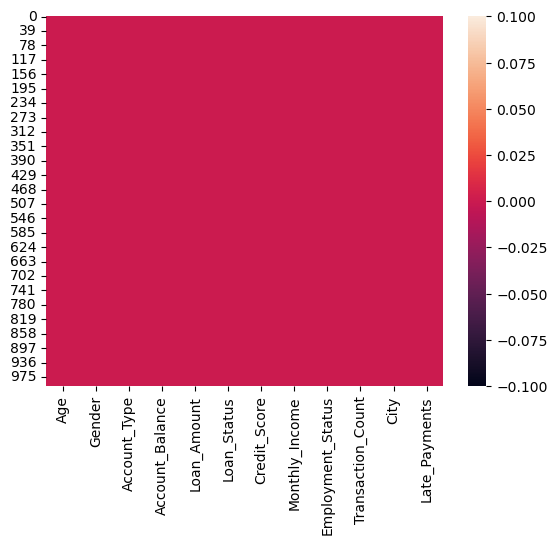

In [32]:
sns.heatmap(data2.isnull())
plt.show()

### here we fill the null values thats why heatmap are not showing  null values

In [33]:
## range of corelation -1 to +1
#neare to -1=strong negative
#neare to +1=strong possitive
#use of corleation:Correlation is used to decide which columns should be used for further analysis or modeling.

In [34]:
data2.corr(numeric_only=True)


,Age,Account_Balance,Loan_Amount,Credit_Score,Monthly_Income,Transaction_Count,Late_Payments
Age,1.000000,-0.004921,-0.024750,-0.075933,0.035958,-0.060662,-0.000531
Account_Balance,-0.004921,1.000000,0.007787,0.059364,-0.006548,0.068070,-0.024898
Loan_Amount,-0.024750,0.007787,1.000000,0.007364,-0.019099,0.000789,-0.028831
Credit_Score,-0.075933,0.059364,0.007364,1.000000,-0.005324,0.033136,-0.047880
Monthly_Income,0.035958,-0.006548,-0.019099,-0.005324,1.000000,0.007620,-0.009469
Transaction_Count,-0.060662,0.068070,0.000789,0.033136,0.007620,1.000000,0.016021
Late_Payments,-0.000531,-0.024898,-0.028831,-0.047880,-0.009469,0.016021,1.000000


Text(0.5, 1.0, 'Correlation between Numeric columns')

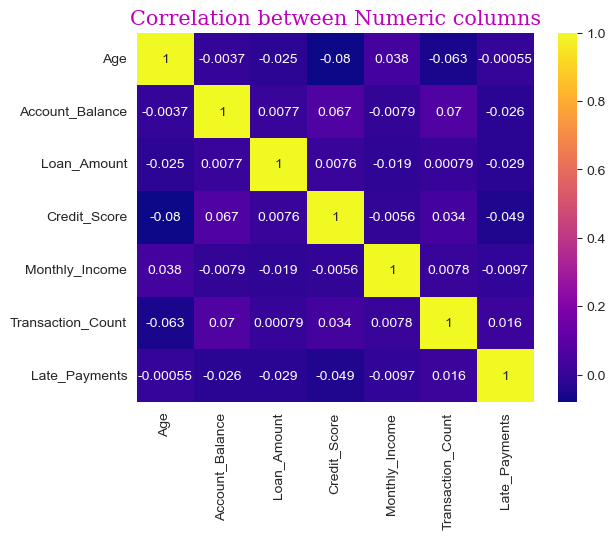

In [87]:
sns.heatmap(numeric_cols.corr(), annot=True, cmap="plasma")
font={"family":"serif","color":"m","size":15}
plt.title("Correlation between Numeric columns",fontdict=font)


In [36]:
#light color=strong corelation
#dark color=week corelation

#### there is no strong correaltion between the numeric columns

### Outlier Detection And Treatment
- to check if there are outliers present in numeric columns
1. kde plot
2. boxplot
3. IQR
4. Zscore

#### age data

<Axes: xlabel='Age'>

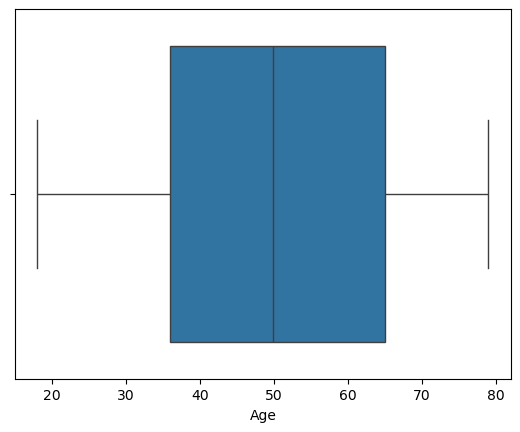

In [37]:
sns.boxplot(data=data2,x="Age")

<Axes: xlabel='Age', ylabel='Density'>

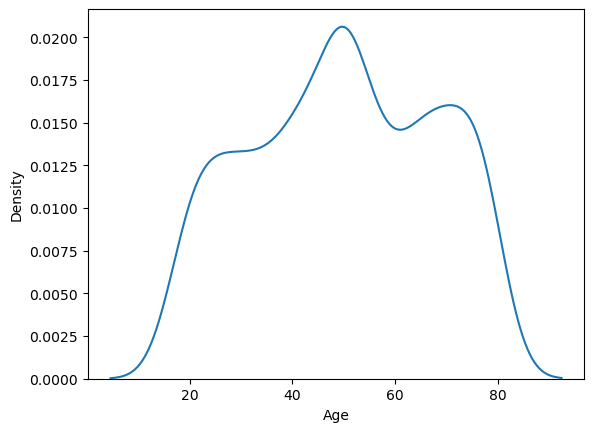

In [38]:
sns.kdeplot(data=data2,x="Age")

In [39]:
from scipy.stats import kurtosis,skew
skewness=skew(data2["Age"])
print(skewness)
kurtosis_=kurtosis(data2["Age"])
print(kurtosis_)

-0.07427752320769702
-1.0788852205997763


#### account balance data

<Axes: ylabel='Account_Balance'>

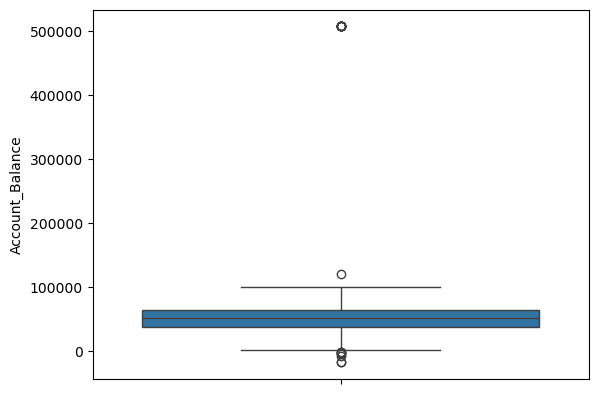

In [40]:
sns.boxplot(data2.Account_Balance)

<Axes: xlabel='Account_Balance', ylabel='Density'>

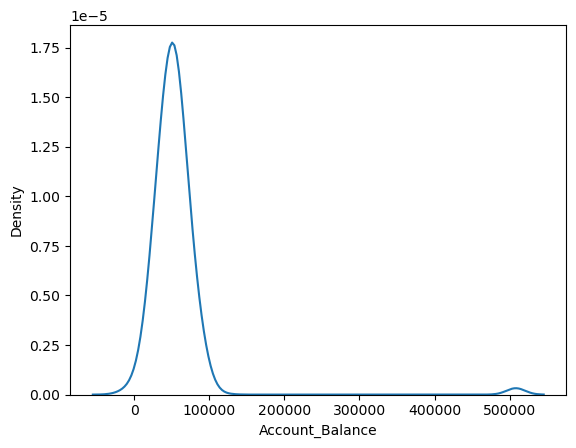

In [41]:
sns.kdeplot(data2.Account_Balance)

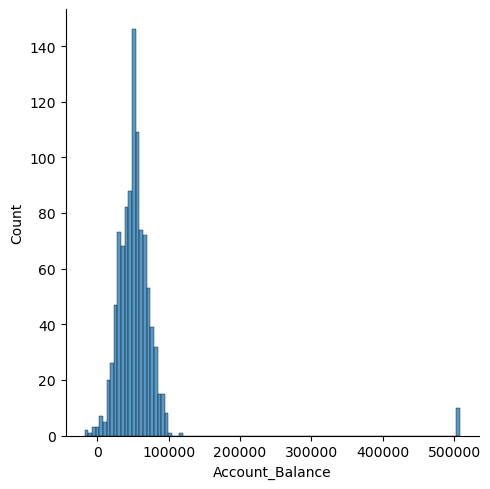

In [42]:
sns.displot(data2.Account_Balance)

In [43]:
skewness=skew(data2["Account_Balance"])
print(skewness)
kurtosis_=kurtosis(data2["Account_Balance"])
print(kurtosis_)

7.695609595419681
68.15131344868567


In [44]:
# by using zscore
from scipy.stats import zscore
outlier=[]
for i in zscore(data2["Account_Balance"]):
    if abs(i)>3:
        outlier.append(i)
print(outlier)
print(len(outlier))




[np.float64(9.181684256145953), np.float64(9.181684256145953), np.float64(9.181684256145953), np.float64(9.181684256145953), np.float64(9.181684256145953), np.float64(9.181684256145953), np.float64(9.181684256145953), np.float64(9.181684256145953), np.float64(9.181684256145953), np.float64(9.181684256145953)]
10


#### Credit Score data

<Axes: xlabel='Credit_Score', ylabel='Density'>

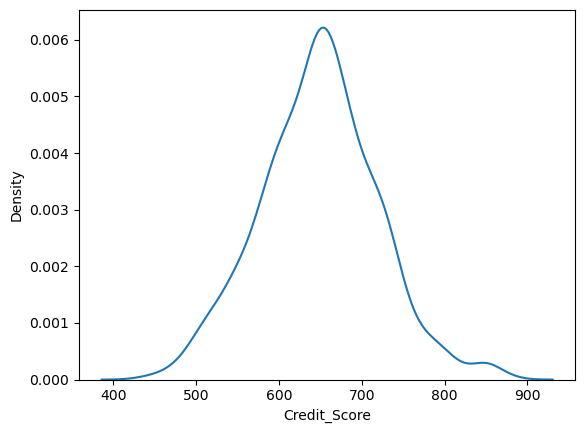

In [45]:
sns.kdeplot(data2.Credit_Score)

<Axes: ylabel='Credit_Score'>

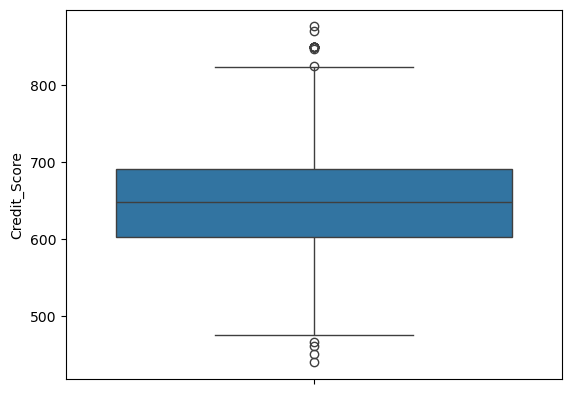

In [46]:
sns.boxplot(data2.Credit_Score)

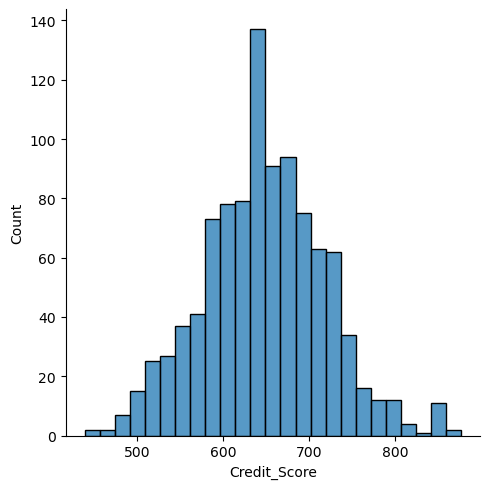

In [47]:
sns.displot(data2.Credit_Score)

### capping the Outlier : replace
- replace all values below the 1st percentilr with  1st percentile 
- replace all values above the 99th percentile with the 99th percentile

In [51]:
first_percentile=np.percentile(data2["Account_Balance"],1)
N99_percentile=np.percentile(data2["Account_Balance"],99)

In [52]:
print(first_percentile)
print(N99_percentile)

5515.6522147000005
123799.11289399647


In [53]:
data2["Account_Balance"]=data2["Account_Balance"].clip(first_percentile,N99_percentile)

<Axes: xlabel='Account_Balance', ylabel='Density'>

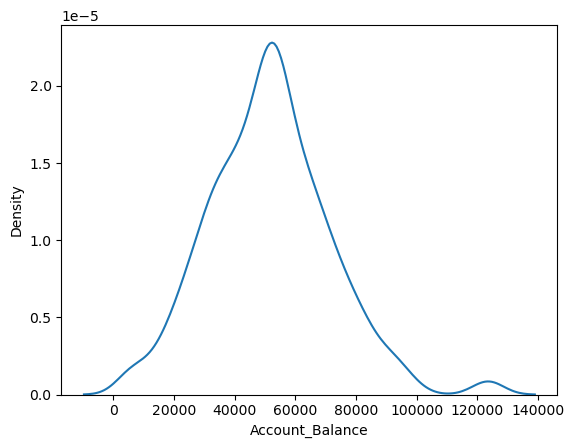

In [54]:
sns.kdeplot(data2.Account_Balance)

## Bivariate

In [66]:
numeric_cols

,Age,Account_Balance,Loan_Amount,Credit_Score,Monthly_Income,Transaction_Count,Late_Payments
0,56.0,50819.73580,0,746.354752,39442.54268,166,6
1,69.0,66589.47858,200000,671.919250,42011.77000,71,0
2,46.0,28527.41988,0,698.094606,33794.29135,297,3
3,32.0,57285.46812,0,752.657860,34311.31156,8,12
4,NaN,33419.25083,50000,572.189382,39926.60102,280,14
...,...,...,...,...,...,...,...
995,18.0,79182.14315,0,703.637008,46429.54365,237,10
996,35.0,33372.01065,0,577.186440,55270.26720,134,12
997,49.0,63951.73201,0,786.163655,55039.07338,279,14
998,64.0,49499.82587,200000,522.523975,49687.38504,18,1


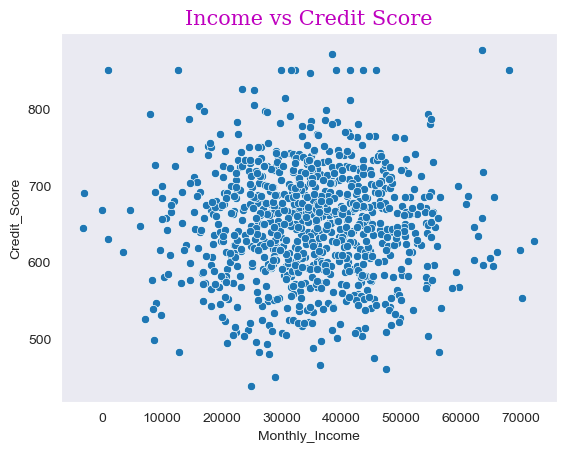

In [73]:
sns.scatterplot(data=numeric_cols,x="Monthly_Income",y="Credit_Score")
font={"family":"serif","color":"m","size":15}
plt.title("Income vs Credit Score",fontdict=font)
plt.show()

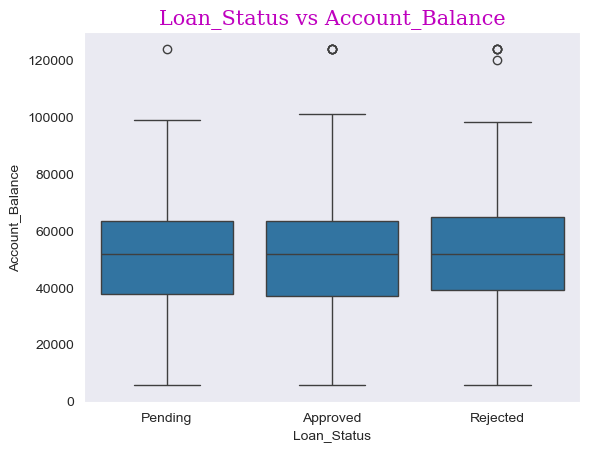

In [82]:
sns.boxplot(data=data2,x="Loan_Status",y="Account_Balance")
font={"family":"serif","color":"m","size":15}
plt.title("Loan_Status vs Account_Balance",fontdict=font)
plt.show()

In [77]:
data2

,Age,Gender,Account_Type,Account_Balance,Loan_Amount,Loan_Status,Credit_Score,Monthly_Income,Employment_Status,Transaction_Count,City,Late_Payments
0,56.000000,Male,FD,50819.73580,0,Pending,746.354752,39442.54268,Self-Employed,166,Pune,6
1,69.000000,Male,Current,66589.47858,200000,Pending,671.919250,42011.77000,Self-Employed,71,Nagpur,0
2,46.000000,Female,Current,28527.41988,0,Approved,698.094606,33794.29135,Salaried,297,Mumbai,3
3,32.000000,Male,Savings,57285.46812,0,Approved,752.657860,34311.31156,Salaried,8,Nagpur,12
4,49.902105,Female,Current,33419.25083,50000,Rejected,572.189382,39926.60102,Salaried,280,Pune,14
...,...,...,...,...,...,...,...,...,...,...,...,...
995,18.000000,Female,FD,79182.14315,0,Approved,703.637008,46429.54365,Salaried,237,Mumbai,10
996,35.000000,Female,Current,33372.01065,0,Pending,577.186440,55270.26720,Salaried,134,Delhi,12
997,49.000000,Male,Current,63951.73201,0,Pending,786.163655,55039.07338,Salaried,279,Mumbai,14
998,64.000000,Male,Savings,49499.82587,200000,Approved,522.523975,49687.38504,Salaried,18,Mumbai,1


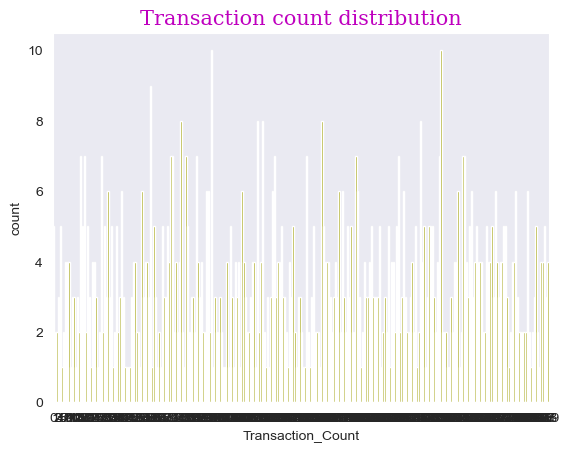

In [81]:
sns.countplot(data=data2,x="Transaction_Count",color="y")
font={"family":"serif","color":"m","size":15}
plt.title("Transaction count distribution",fontdict=font)
plt.show()